# Results Visualization

This notebook provides a visual comparison of the baseline models evaluated in the previous step.
While the numerical results offer a structured overview, visualizations make the performance differences between the models easier to interpret.
The focus is on the macro‑F1, weighted‑F1, and accuracy scores, which together give a balanced view of how effectively each model handles the sentiment classification task.

In [59]:
import sys
from pathlib import Path

project_root = Path().resolve()
while not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.append(str(project_root))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.model_repository import ModelRepository
from src.utils.model_plotter import ModelPlotter
from src.utils.loaders import load_metrics, load_class_metrics, load_confusion_data, load_misclassifications, load_learning_curves, load_feature_importances, load_model_sizes
from src.utils.utils import build_model_colors
import pandas as pd

In [61]:
repo = ModelRepository()
df = load_metrics(repo)
df

,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,config
0,Logistic Regression,0.867550,0.817436,0.867594,0.813197,0.825124,"{'model': 'Logistic Regression', 'params': {'C..."
1,Naive Bayes,0.801325,0.654826,0.778570,0.833301,0.641588,"{'model': 'Naive Bayes', 'params': {'alpha': 1..."
2,Linear SVM,0.898455,0.851510,0.898199,0.849079,0.857341,"{'model': 'Linear SVM', 'params': {'C': 1.0, '..."


In [62]:
model_colors = build_model_colors(
    models= df["model"].unique(),
    palette='magma'
    )

## Overall Model Performance
To make the performance differences between the baseline models easier to interpret, the key evaluation metrics are visualized using bar charts.
The focus lies on the macro‑F1 score, weighted‑F1 score, and accuracy, as these metrics together provide a balanced view of how effectively each model handles the sentiment classification task.

Linear SVM achieves the highest accuracy of all models, outperforming both Logistic Regression and Naive Bayes. Logistic Regression performs slightly below the SVM but still delivers strong and stable results.

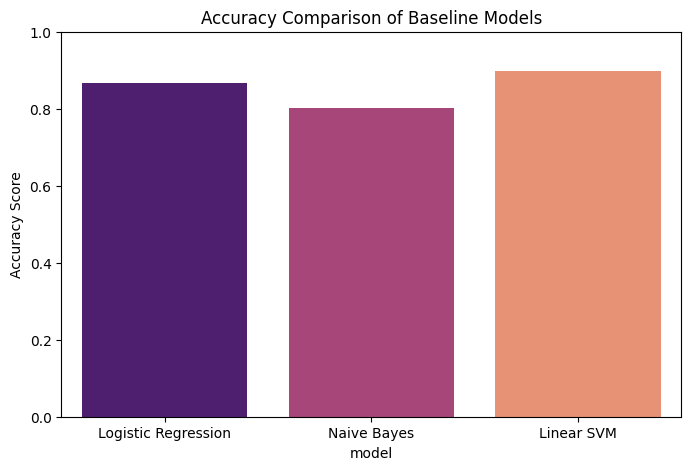

In [63]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="model", y="accuracy", hue='model', palette=model_colors)
plt.ylabel("Accuracy Score")
plt.title("Accuracy Comparison of Baseline Models")
plt.ylim(0, 1)
plt.show()

The macro-averaged evaluation metrics provide a balanced view of model performance across all sentiment classes, independent of class frequency.

Linear SVM achieves the strongest overall results, with a Macro F1 score of 0.8515 and consistenly high Macro Precision and Macro Recall. This indicates that the model maintains reliable performance across all sentiment categories and handles minority classes effectively. 

Logistic Regression follows closely, reaching a Macro F1 score of 0.8174. Its Macro Precision and Macro recall values demonstrate stable and well-distributed performance across classes.

Naive Bayes shows a significantly lower Macro F1 score of 0.6548 and reduced Macro Recall, despite achieving comparatively high Macro Precision. This pattern indicates that the model produces confident predicitions but fails to identify a substantial portion of true instances.

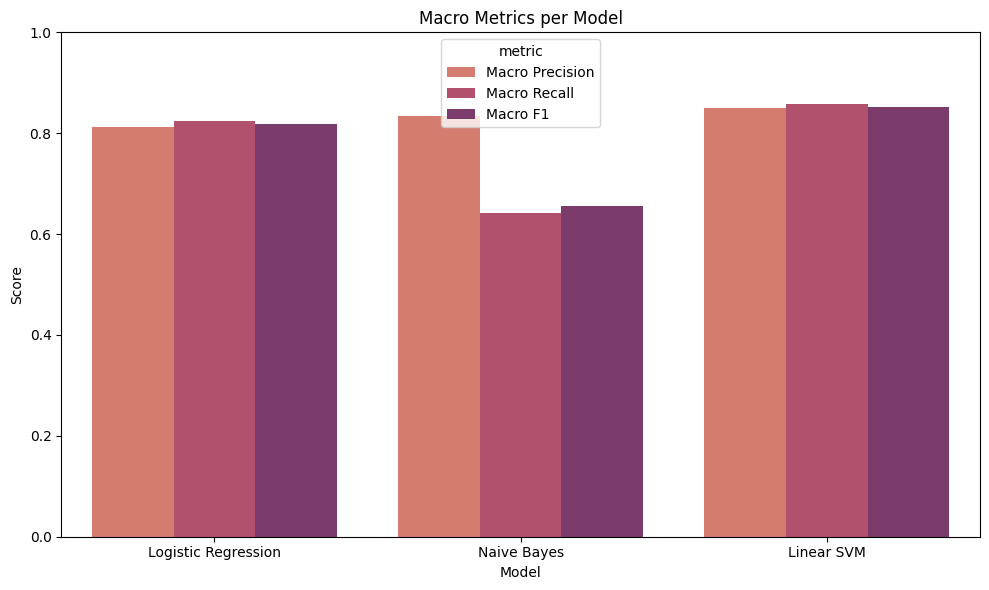

In [64]:
plotter = ModelPlotter(repo)
plotter.plot_macro_metrics(df, model_colors="flare")

The radar chart provides a consolidated visual comparison of the three models across the macro‑averaged evaluation metrics. The shape and spread of each model’s polygon highlight the balance and consistency of its performance.

Linear SVM forms the largest and most uniformly expanded polygon in the chart. Its values for macro‑F1, macro‑precision, and macro‑recall are all high and closely aligned, indicating a well‑balanced model that performs reliably across all sentiment classes. The symmetry of the SVM’s area reflects strong generalization and stable behavior, particularly in handling minority classes.

Logistic Regression shows a slightly smaller but still cohesive polygon. Its metrics cluster closely together, demonstrating consistent performance across all three macro measures. Although its overall area is smaller than that of the SVM, the shape remains balanced.

Naive Bayes, in contrast, produces a noticeably irregular and smaller polygon. The model reaches relatively high macro‑precision but falls significantly behind in macro‑recall and macro‑F1. This imbalance creates a skewed shape in the radar chart, visually emphasizing that Naive Bayes identifies fewer true instances across classes despite being confident in the predictions it does make.

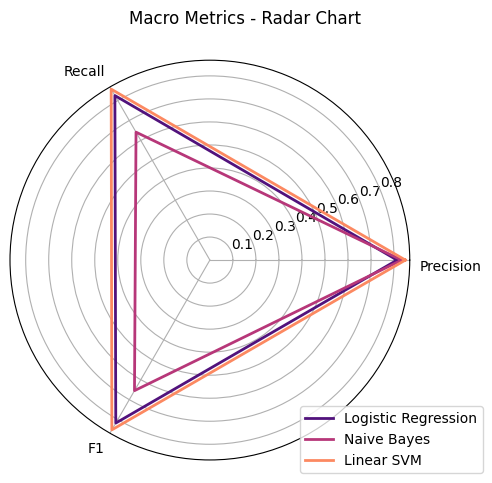

In [65]:
plotter.plot_radar_chart(
    df_metrics=df,
    metric_cols=["macro_precision", "macro_recall", "macro_f1"],
    figsize=(5,5),
    model_colors=model_colors,
    title="Macro Metrics - Radar Chart"
    )

## Class‑Level Performance Analysis

A deeper understanding of model behavior requires examining performance at the class level rather than relying solely on aggregated metrics. This section provides a detailed breakdown of class‑specific strengths and weaknesses for all evaluated models.

The analysis begins with comparing the F1 scores for each sentiment class across the three models. This visualization highlights how consistently each model distinguishes between positive, neutral, and negative financial expressions, and reveals where performance diverges across classes.

The Linear SVM consistently achieves the strongest results, followed by Logistic Regression, while Naive Bayes shows substantial weaknesses especially in the negative class.

Across all models, the neutral class exhibits the highest F1 scores. Linear SVM reaches 0.9589, Logistic Regression 0.9336, and Naive Bayes 0.9057. This indicates that neutral sentiment is the easiest to identify, likely due to a larger number of training examples.

The positive class shows moderate performance. Linear SVM achieves 0.8111, Logistic Regression 0.7706, and Naive Bayes 0.6855. These values suggest that positive sentiment is more challenging to detect than neutral sentiment, but still handled reasonably well by the linear models.

The negative class is the most difficult for all models. Linear SVM reaches 0.7846, Logistic Regression 0.7481, while Naive Bayes drops sharply to 0.3733. This steep decline for Naive Bayes indicates significant difficulty in capturing negative sentiment cues.

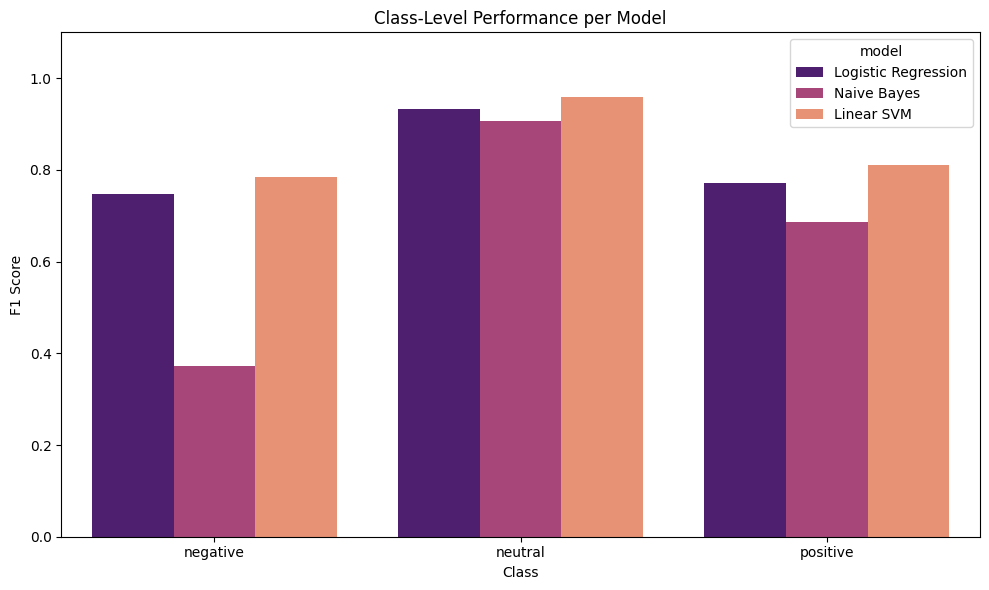

In [66]:
df_class_results = load_class_metrics(repo)
plotter.plot_class_performances(df_class_results, model_colors=model_colors)

The normalized confusion matrices provide a detailed view of how each model distinguishes between the three sentiment classes. Because each row is normalized, the values represent the proportion of samples from a true class that were assigned to each predicted class. This allows a direct comparison of class‑wise reliability, independent of class imbalance.

Across all models, the neutral class is the most consistently recognized. The Linear SVM achieves the highest accuracy for this class, correctly identifying 96.4% of neutral samples. Logistic Regression follows with 93.5%, while Naive Bayes reaches 94.96%. This strong performance across models suggests that neutral financial language exhibits clearer and more stable patterns than positive or negative sentiment.

The negative class shows the largest performance differences. Linear SVM correctly classifies 83.6% of negative samples, while Logistic Regression achieves 80.3%. In contrast, Naive Bayes struggles significantly, correctly identifying only 22.9% of negative instances. More than half of the negative samples (57.4%) are misclassified as positive by Naive Bayes, indicating that the model systematically interprets negative sentiment as positive.

The positive class is moderately challenging for all models. Linear SVM correctly predicts 77.2% of positive samples, Logistic Regression 73.7%, and Naive Bayes 74.6%. Both linear models show similar misclassification patterns: positive samples are often confused with negative sentiment, around 13% for both models. Naive Bayes, on the other hand, tends to misclassify positive samples as neutral (25.4%).

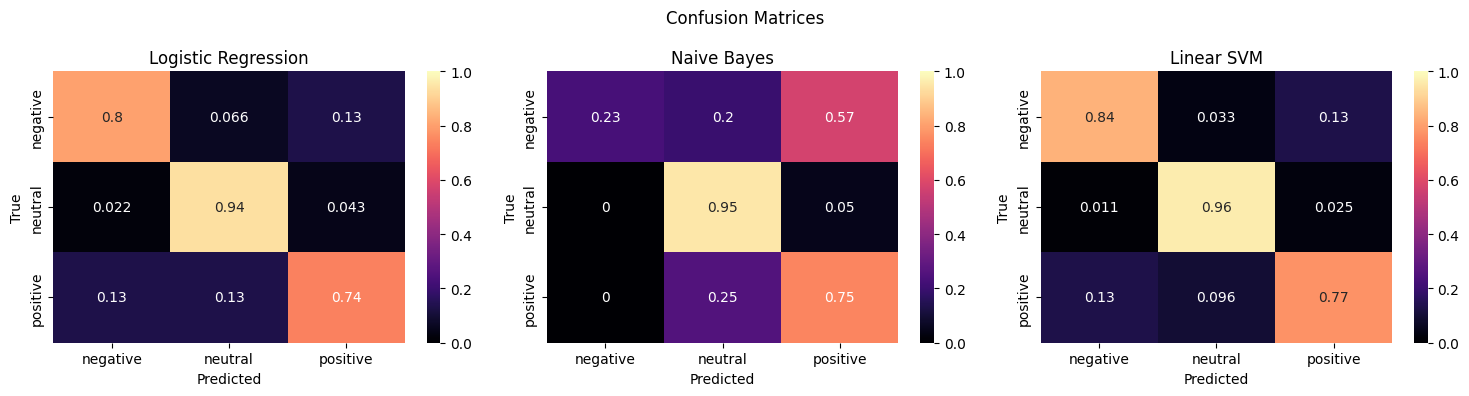

In [67]:
cm_list = load_confusion_data(repo)
plotter.plot_confusion_matrices(cm_list, cmap="magma")

The misclassification heatmaps provide a focused view of the specific error pathways each model produces. Unlike the confusion matrices, which show both correct and incorrect predictions, these heatmaps isolate only the misclassified samples. This makes systematic error patterns more visible and highlights where each model struggles to separate sentiment classes. Across all models, the most prominent misclassification pattern is the confusion between neutral and positive sentiment.

Logistic Regression exhibits a relatively balanced distribution of misclassifications. Negative samples are most often misclassified as positive (71.4%), while neutral samples are primarily confused with positive sentiment (68.6%). Positive samples show a nearly even split between being misclassified as negative (49.3%) and neutral (50.7%). This pattern indicates that Logistic Regression struggles to maintain clear boundaries between the three sentiment categories, particularly when distinguishing positive sentiment from the other two classes.

Naive Bayes shows a far more polarized error structure. Negative samples are predominantly misclassified as positive (65.3%), and neutral samples are almost exclusively misclassified as positive (100%). Positive samples are overwhelmingly misclassified as neutral (99.2%). These patterns reveal a strong bias toward predicting positive or neutral sentiment when uncertainty is present.

Linear SVM displays a more structured and interpretable misclassification pattern. Negative samples are most frequently misclassified as positive (86.7%), while neutral samples are again primarily confused with positive sentiment (69.2%). Positive samples, however, show the opposite trend: they are more often misclassified as negative (64.9%) than neutral (35.1%). This bidirectional confusion between positive and negative sentiment suggests that the SVM draws a sharper boundary between neutral and non‑neutral classes, but still encounters difficulty separating optimistic from pessimistic financial language.

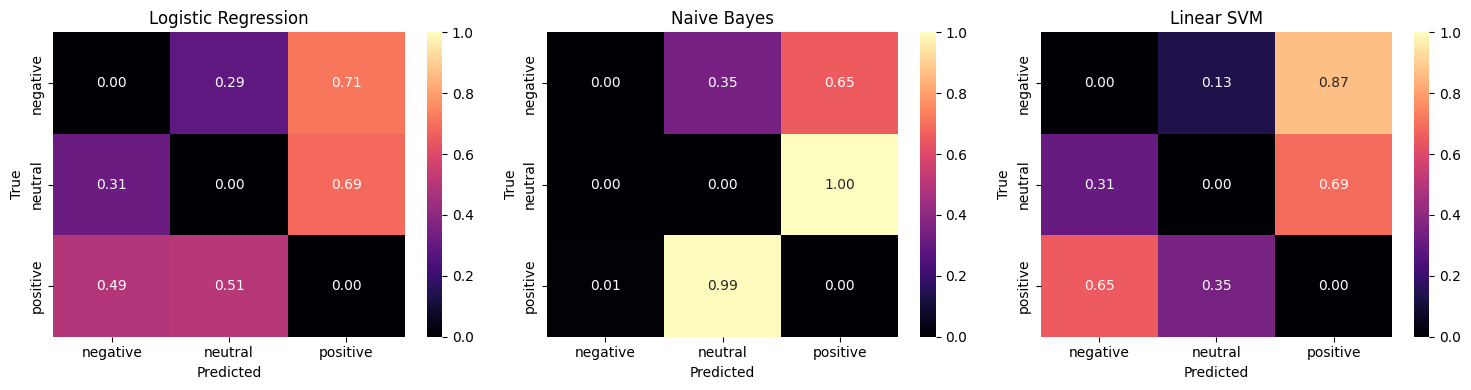

In [68]:
mscls_list = load_misclassifications(repo)
plotter.plot_misclassifications(mscls_list, cmap="magma")

The class‑wise error‑rate comparison provides a clear view of how frequently each model misclassifies samples from each sentiment category. Because the error rates are normalized by the true class counts, they directly reflect how reliably each model handles each sentiment class, independent of class imbalance.

Across all models, the neutral class exhibits the lowest error rates. Linear SVM achieves the strongest performance with an error rate of only 0.0093, followed by Logistic Regression at 0.0367 and Naive Bayes at 0.0288. This confirms that neutral sentiment is the most easily distinguishable category in the dataset, likely due to a larger number of training examples.

The positive class shows moderate error rates. Linear SVM again performs best with an error rate of 0.0649, while Logistic Regression reaches 0.1246. Naive Bayes performs noticeably worse at 0.2246.

The negative class displays the most pronounced differences between models. Linear SVM and Logistic Regression achieve similar error rates (0.0495 and 0.0462 respectively), demonstrating stable performance. In contrast, Naive Bayes shows a dramatically higher error rate of 0.6667, meaning that two‑thirds of all negative samples are misclassified. This aligns with the patterns observed in the misclassification heatmaps, where Naive Bayes frequently confuses negative sentiment with positive or neutral categories.

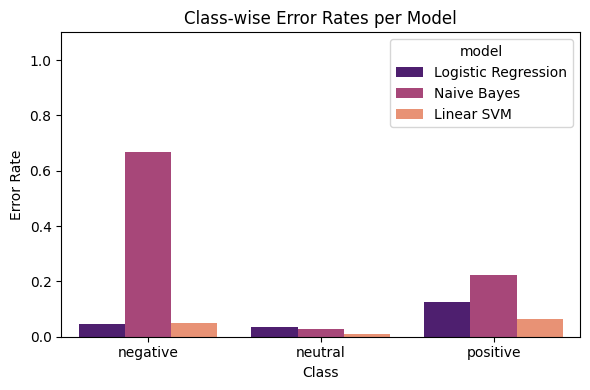

In [69]:
dataset = pd.read_csv(repo.root / "data/processed/clean_data.csv", keep_default_na=False)
class_counts = dataset["label"].value_counts()
plotter.plot_error_rates(mscls_list, class_counts, model_colors)

## Learning Behavior

Understanding the learning behavior of each model provides valuable insight into how effectively they generalize from the training data and how efficiently they converge during optimization. The learning curves presented in this section illustrate the relationship between training size, training performance, and validation performance for each model. By examining these curves, it becomes possible to assess whether a model is underfitting, overfitting, or learning in a stable and predictable manner.

Across all models, the training curves start higher than the validation curves. 

The Linear SVM shows a high‑variance pattern at small training sizes. The training accuracy is nearly perfect, while the validation accuracy begins very low. As more data is added, the validation curve rises steadily and significantly, eventually reaching over 0.71. The training curve decreases slightly but remains high, and the gap between the curves narrows. This indicates that the SVM benefits strongly from additional data and continues to generalize better as the dataset grows.

Logistic Regression exhibits a similar but more moderate trend. Training accuracy decreases more noticeably as the dataset grows, reflecting the model’s simpler linear decision boundary. Validation accuracy improves steadily from 0.35 to 0.69, showing that Logistic Regression also benefits from more data, though at a slower rate than the SVM. The persistent but shrinking gap between the curves indicates mild variance. The model is not overfitting severely, but its representational capacity limits how much it can improve. Logistic Regression learns efficiently but cannot fully capture the nuanced sentiment patterns present in financial text.

Naive Bayes, in contrast, demonstrates a high‑bias learning pattern. Both training and validation scores start low, and although they improve with more data, the gains are modest. Validation accuracy increases from 0.13 to 0.58, while training accuracy fluctuates between 0.44 and 0.77. The small and relatively stable gap between the curves indicates low variance. Naive Bayes does not overfit, even with limited data. The model reaches its performance ceiling early, and additional data yields only incremental improvements.

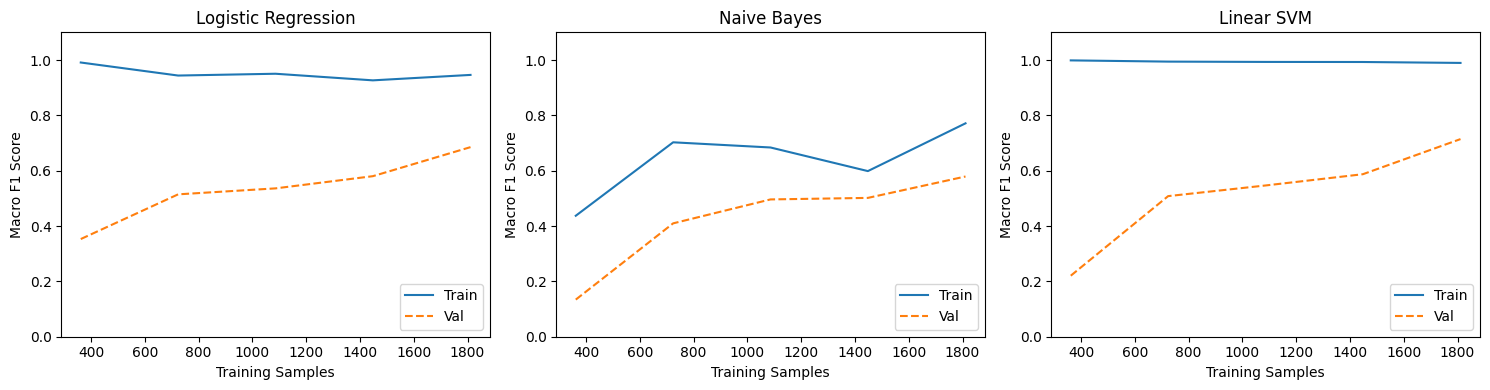

In [70]:
lc_list = load_learning_curves(repo)
plotter.plot_learning_curves(lc_list)

## Model Interpretability

This chapter focuses on feature‑importance visualizations for the two linear models used in this study: the Linear SVM and Logistic Regression. Both models learn a weight for each feature, indicating how strongly that feature contributes to predicting a particular sentiment class.

The feature‑importance results for the Linear SVM and Logistic Regression reveal how differently the two linear models weight linguistic cues when predicting sentiment. Although both models rely on similar types of features, their coefficient rankings show meaningful differences in how they interpret sentiment‑bearing terms.

Both models identify strongly negative financial verbs such as decreased, fell, dropped, fall, lower, slipped, and declined as highly influential. However, the relative importance of these terms differs noticeably. Logistic Regression assigns its highest coefficient to decreased (3.72), making it the single most influential feature in the model. In contrast, while decreased is also the top feature for the SVM, its coefficient (3.31) is lower, and the SVM distributes importance more evenly across a broader set of negative indicators. This suggests that Logistic Regression relies more heavily on a few dominant cues, whereas the SVM integrates a wider range of signals when forming its decision boundary.

A striking difference emerges in the presence of positive‑leaning or recovery‑related terms. Logistic Regression includes profit among its top features, ranking it fifth with a coefficient of 1.67. This indicates that the model considers profit‑related language a strong sentiment cue. In contrast, profit does not appear in the SVM’s top 20 features at all. Similarly, Logistic Regression includes decline as a top feature, while the SVM does not. Conversely, the SVM highlights several domain‑specific financial loss terms that Logistic Regression does not rank among its top features. Terms such as pretax loss and operating loss appear prominently in the SVM’s top 20, indicating that the SVM is particularly sensitive to explicit loss‑related expressions. Logistic Regression, however, does not include these terms in its top features, suggesting that it generalizes loss signals more broadly through verbs like fell, dropped, and declined rather than through specific financial terminology.



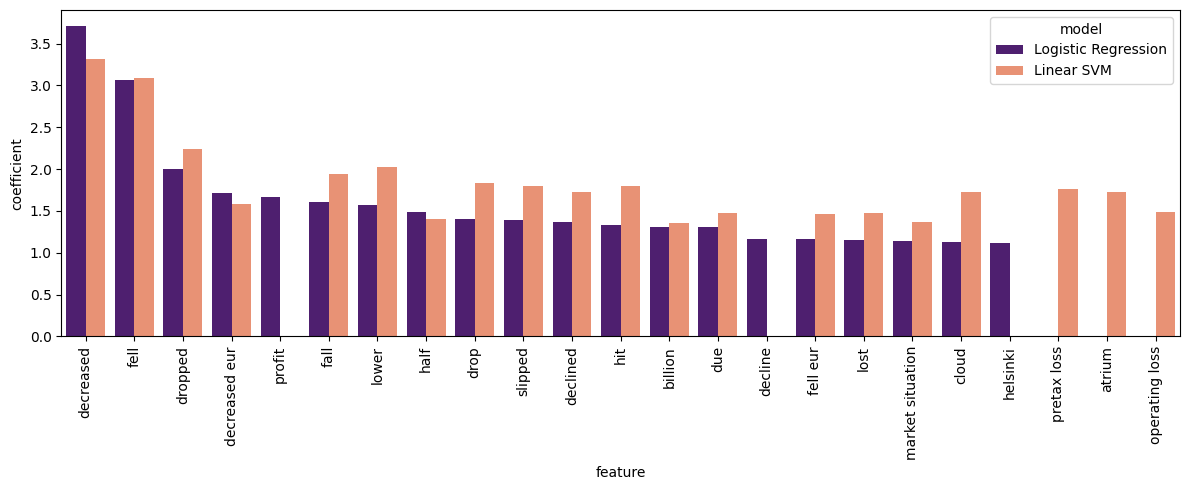

In [71]:
fi_df = load_feature_importances(repo)
plt.figure(figsize=(12, 5))
sns.barplot(
    data=fi_df,
    x="feature",
    y="coefficient",
    hue="model",
    palette=model_colors
)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Model Efficiency and Complexity

Evaluating model performance in isolation provides only part of the picture. In practical applications the efficiency and complexity of a model become just as important as its predictive accuracy. This chapter examines how the three models balance predictive power with computational footprint.

On the left, a scatter plot visualizes the relationship between model size in kilobytes and macro‑F1 performance. This view highlights the trade‑off between complexity and accuracy: larger models often achieve higher performance, but at the cost of increased memory usage and potentially slower inference. By comparing the models along these two axes, it becomes clear which ones deliver strong performance efficiently and which ones require more substantial resources to reach their accuracy levels.

On the right, a bar plot presents the macro‑F1‑per‑kilobyte ratio, offering a direct measure of how much predictive value each model provides per unit of model size. This metric emphasizes efficiency: a model with a high F1/KB ratio delivers strong performance while remaining lightweight, making it particularly suitable for deployment in environments where memory or processing power is limited.

Logistic Regression and Linear SVM are nearly identical in size at roughly 188 KB, reflecting their similar linear architectures and sparse weight vectors. Naive Bayes, in contrast, is noticeably larger at 258 KB, due to its need to store full conditional probability distributions for each feature across all classes. When these sizes are compared against macro‑F1 performance in the scatter plot, the two linear models cluster together as compact yet high‑performing solutions, while Naive Bayes occupies a region of higher complexity and lower accuracy.

The efficiency bar plot further emphasizes this contrast. Because Logistic Regression and Linear SVM achieve substantially higher Macro F1 scores with smaller model sizes, their F1‑per‑kilobyte ratios are significantly stronger. Naive Bayes, despite being the largest model, delivers the lowest predictive value per unit of memory. Together, these results highlight that the linear models offer the most favorable balance between accuracy and computational efficiency.

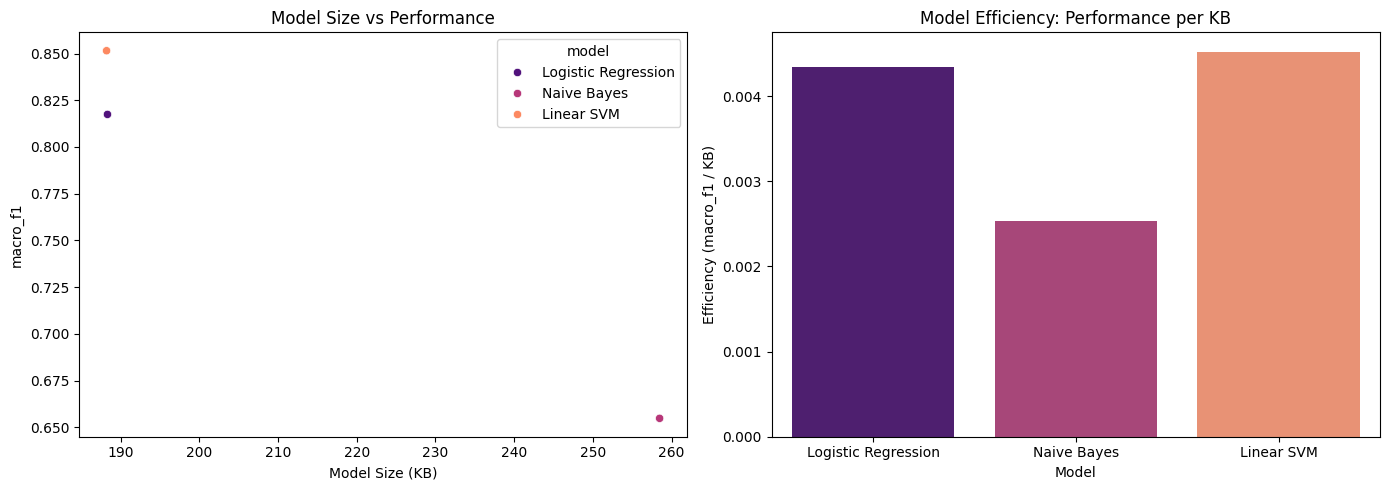

In [72]:
sizes_df = load_model_sizes(repo)
plotter.plot_model_sizes_and_efficiencies(df, sizes_df, "macro_f1", model_colors)

## Conclusion

The comprehensive evaluation of the three sentiment‑classification models provides a clear and coherent picture of their strengths, limitations, and practical suitability for financial sentiment analysis. Across all analyses, the Linear SVM consistently emerges as the most reliable and well‑balanced model. It achieves the highest Macro F1 scores, demonstrates stable class‑level performance, exhibits structured and interpretable misclassification patterns, and benefits substantially from additional training data. Its feature‑importance profile shows a nuanced understanding of domain‑specific financial terminology, and its compact model size makes it both accurate and efficient.

Logistic Regression performs moderately well, offering competitive accuracy and strong interpretability. Its learning behavior shows steady improvement with more data, and its feature‑importance rankings highlight a focused reliance on a smaller set of dominant sentiment cues. However, it exhibits more confusion between sentiment classes and a narrower linguistic sensitivity compared to the SVM. 

Naive Bayes consistently underperforms across all evaluation dimensions. Its high error rates, especially for negative sentiment, its biased misclassification patterns, and its limited learning capacity reflect the constraints imposed by its independence assumptions. Although it is the largest model in terms of memory footprint, it delivers the lowest predictive value per kilobyte, making it the least efficient choice for this task.